# Banking Customer Churn Prediction 
**Team:** atasikolexi05  
**Goal:** Predict churn with business costs FN=40,000, FP=500  
**Primary metric:** PR-AUC  
**Key principle:** No future information, no test data in training, no leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [2]:
train = pd.read_csv('../Data/ChurnZero_dataset_v1.csv')
test = pd.read_csv('../Data/ChurnZero_test_v1.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (8101, 98)
Test shape: (2026, 97)


In [3]:
# Look for plausible target column names
possible_targets = ['churn', 'churned', 'churn_flag', 'target', 'churned_flag', 'is_churned', 'churn_label']
found_targets = [col for col in train.columns if col.lower() in possible_targets]

if found_targets:
    target_col = found_targets[0]
    print(f"Target column detected: '{target_col}'")
else:
    # If not found, let user input manually
    print("Columns in train:", train.columns.tolist())
    target_col = input("Enter the exact target column name: ")

print("Target distribution:")
print(train[target_col].value_counts(normalize=True))

Target column detected: 'churn'
Target distribution:
churn
0    0.839279
1    0.160721
Name: proportion, dtype: float64


In [4]:
# Compute correlation of ALL numeric columns with target
corr_all = []
for col in train.columns:
    if col != target_col and train[col].dtype in ['int64', 'float64']:
        corr = train[[col, target_col]].corr().iloc[0,1]
        corr_all.append((col, corr))

corr_all.sort(key=lambda x: -abs(x[1]))
print("Top 20 correlations (absolute value) with target:")
for col, corr in corr_all[:20]:
    print(f"  {col:40s} {corr:+.4f}")

Top 20 correlations (absolute value) with target:
  balance_decline_percentage               +0.4559
  cash_withdrawal_count                    -0.4258
  last_contacted_days                      +0.3837
  total_trans_count                        -0.3725
  monthly_transaction_count                -0.3676
  minimum_due_paid_flag                    -0.3671
  upi_transaction_count                    -0.3441
  debit_card_transaction_count             -0.3348
  referral_count                           -0.3096
  avg_monthly_balance                      -0.3018
  current_balance                          -0.2939
  net_banking_transaction_count            -0.2930
  total_ct_chng_q4_q1                      -0.2865
  customer_lifetime_value                  -0.2730
  total_revolving_bal                      -0.2676
  loyalty_program_member                   -0.2528
  fixed_deposit_flag                       -0.2026
  credit_utilization_ratio                 -0.1885
  total_trans_amt               

In [5]:
# Check categorical columns for unique mapping to target
cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    if col != target_col:
        # Check if each category value maps perfectly to churn or non-churn
        cross = pd.crosstab(train[col], train[target_col])
        # If any category has 0 in one column and >0 in the other, it might be leaky
        if (cross.iloc[:,0] == 0).any() or (cross.iloc[:,1] == 0).any():
            print(f"Column '{col}' may be leaky:")
            print(cross)
            print()

In [6]:
# Find columns with suspiciously high correlation to target
high_corr = []
for col in train.columns:
    if col != target_col and train[col].dtype in ['int64', 'float64']:
        corr = abs(train[[col, target_col]].corr().iloc[0,1])
        if corr > 0.7:   # lowered threshold
            high_corr.append((col, corr))
high_corr.sort(key=lambda x: -x[1])
print("Columns with correlation > 0.7 to target:")
for col, corr in high_corr:
    print(f"  {col}: {corr:.4f}")

Columns with correlation > 0.7 to target:


In [7]:
# Check for any column that is identical to target (or its inverse)
for col in train.columns:
    if col != target_col and train[col].dtype in ['int64', 'float64'] and train[col].nunique() <= 2:
        if (train[col] == train[target_col]).all():
            print(f" Column '{col}' is IDENTICAL to target – DROP IT!")
        elif (train[col] == 1 - train[target_col]).all():
            print(f" Column '{col}' is perfect inverse of target – DROP IT!")

In [8]:
# Compute correlation of every numeric column with the target
correlations = []
for col in train.columns:
    if col != target_col and train[col].dtype in ['int64', 'float64']:
        corr = train[[col, target_col]].corr().iloc[0,1]
        if abs(corr) > 0.5:   # high correlation threshold
            correlations.append((col, corr))

correlations.sort(key=lambda x: -abs(x[1]))
print("Columns with |correlation| > 0.5 to target:")
for col, corr in correlations:
    print(f"  {col}: {corr:.4f}")

Columns with |correlation| > 0.5 to target:
  total_digital_logins: -0.5078


In [9]:
# Keywords that often indicate post-churn or future information
leaky_keywords = [
    'resolution', 'satisfaction', 'nps', 'feedback', 'closed', 'exited',
    'cancelled', 'inactive', 'last_active', 'days_since', 'churn_risk',
    'attrition', 'survival', 'exit', 'recovery', 'winback'
]

leaky_cols = []
for col in train.columns:
    if any(kw in col.lower() for kw in leaky_keywords):
        leaky_cols.append(col)

print("Potential time‑leakage columns (may contain future info):")
for col in leaky_cols:
    print(f"  {col}")

Potential time‑leakage columns (may contain future info):
  account_inactive_days
  complaint_resolution_time
  satisfaction_score
  nps_score
  customer_feedback_sentiment


In [10]:
# For each column, check if it has a unique value for all churners (or all non-churners)
for col in train.columns:
    if col != target_col and train[col].dtype in ['int64', 'float64']:
        # Check if column is constant for churn=1
        churn_vals = train[train[target_col]==1][col].unique()
        non_churn_vals = train[train[target_col]==0][col].unique()
        if len(churn_vals) == 1 and len(non_churn_vals) > 1:
            print(f"Column '{col}' has single value {churn_vals[0]} for ALL churners → LEAKAGE")
        elif len(non_churn_vals) == 1 and len(churn_vals) > 1:
            print(f"Column '{col}' has single value {non_churn_vals[0]} for ALL non-churners → LEAKAGE")

Column 'mobile_banking_active_flag' has single value 1 for ALL non-churners → LEAKAGE
Column 'unresolved_complaint_count' has single value 0 for ALL non-churners → LEAKAGE
Column 'escalation_count' has single value 0 for ALL non-churners → LEAKAGE
Column 'campaign_response_count' has single value 0 for ALL churners → LEAKAGE


In [11]:
# Run all above and compile a drop list
suspicious = set()
# Add from correlation > 0.7
for col, corr in correlations:
    if abs(corr) > 0.7:
        suspicious.add(col)
# Add from leaky keywords
suspicious.update(leaky_cols)

print("\n----- COLUMNS TO DROP -----")
for col in sorted(suspicious):
    print(f"  {col}")
print(f"\nTotal suspicious columns: {len(suspicious)}")


----- COLUMNS TO DROP -----
  account_inactive_days
  complaint_resolution_time
  customer_feedback_sentiment
  nps_score
  satisfaction_score

Total suspicious columns: 5


In [12]:
# Leaky keywords (post-churn or future info)
leaky_keywords = [
    'churn', 'closed', 'exited', 'inactive', 'cancelled', 
    'churned', 'is_churn', 'exit', 'attrited', 'lost_customer',
    'resolution', 'satisfaction', 'nps', 'feedback',
    'last_active', 'days_since', 'attrition', 'survival', 'winback',
    'days_since', 'last_', 'recent', 'recency',
    'since', 'elapsed', 'remaining', 'left'
]

# Explicit column names to drop (from constant checks)
explicit_drop = [
    'mobile_banking_active_flag',
    'unresolved_complaint_count',
    'escalation_count',
    'campaign_response_count'
]

# Combine
def find_leaky_columns(df, target):
    leaky = []
    for col in df.columns:
        if col == target:
            continue
        if any(kw in col.lower() for kw in leaky_keywords):
            leaky.append(col)
        if col in explicit_drop:
            leaky.append(col)
        # Also check near-perfect correlation (lower threshold to 0.7)
        if df[col].dtype in ['int64', 'float64'] and df[col].nunique() > 1:
            corr = abs(df[[col, target]].corr().iloc[0,1])
            if corr > 0.7:
                leaky.append(col)
    return list(set(leaky))   # remove duplicates

leaky_cols = find_leaky_columns(train, target_col)
print("Dropping these leaky columns:", leaky_cols)

X = train.drop(columns=[target_col] + leaky_cols)
y = train[target_col]
# For test, drop same columns if they exist
test_leaky = [col for col in leaky_cols if col in test.columns]
X_test = test.drop(columns=test_leaky)

print(f"Features remaining: {X.shape[1]}")

Dropping these leaky columns: ['last_contacted_days', 'escalation_count', 'satisfaction_score', 'nps_score', 'campaign_response_count', 'last_login_days', 'customer_feedback_sentiment', 'mobile_banking_active_flag', 'account_inactive_days', 'unresolved_complaint_count', 'last_campaign_response_days', 'complaint_resolution_time']
Features remaining: 85


In [13]:
# Only drop true identifier columns — not legitimate features
id_cols = ['customer_id']  # be explicit, don't pattern-match
customer_ids = test['customer_id']

X = X.drop(columns=['customer_id'], errors='ignore')
X_test = X_test.drop(columns=['customer_id'], errors='ignore')
print(f"Final feature count: {X.shape[1]}")

Final feature count: 84


In [14]:
print("Missing values per column (top 10):")
print(X.isnull().sum().sort_values(ascending=False).head(10))

# Correlation with target (for insight only, not used in training)
numeric_feats = X.select_dtypes(include=[np.number]).columns
corrs = pd.Series(index=numeric_feats, dtype=float)
for col in numeric_feats:
    if X[col].nunique() > 1:
        corrs[col] = abs(X[col].corr(y))
print("\nTop 5 absolute correlations (non-leaky features):")
print(corrs.sort_values(ascending=False).head(5))

Missing values per column (top 10):
app_rating_given             4541
age                             0
emi_amount                      0
failed_login_count              0
digital_transaction_ratio       0
website_login_count             0
mobile_app_login_count          0
prepayment_flag                 0
loan_default_risk_score         0
emi_payment_delay_count         0
dtype: int64

Top 5 absolute correlations (non-leaky features):
total_digital_logins          0.507769
balance_decline_percentage    0.455938
mobile_app_login_count        0.427283
cash_withdrawal_count         0.425809
email_open_rate               0.411138
dtype: float64


In [15]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric: {len(numeric_cols)}")
print(f"Categorical: {len(categorical_cols)}")

Numeric: 70
Categorical: 14


In [16]:
# Numeric: fill with median from train
for col in numeric_cols:
    median_val = X[col].median()
    X[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)

# Categorical: fill with mode from train
for col in categorical_cols:
    mode_val = X[col].mode()[0] if not X[col].mode().empty else 'missing'
    X[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True)

print("Missing values filled.")

Missing values filled.


In [17]:
# One-hot encoding
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align test columns to train
missing_in_test = set(X.columns) - set(X_test.columns)
for col in missing_in_test:
    X_test[col] = 0
extra_in_test = set(X_test.columns) - set(X.columns)
X_test = X_test.drop(columns=extra_in_test)
X_test = X_test[X.columns]

print(f"Encoded feature count: {X.shape[1]}")

Encoded feature count: 119


In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


In [19]:
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}")
print(f"Train churn rate: {y_train.mean():.4f}")
print(f"Val churn rate: {y_val.mean():.4f}")

Train size: 6480, Validation size: 1621
Train churn rate: 0.1606
Val churn rate: 0.1610


In [20]:
# Sanity check: train a shallow decision tree (depth=1) on each feature alone
from sklearn.tree import DecisionTreeClassifier

single_feat_aucs = []
for col in X.columns:
    dt = DecisionTreeClassifier(max_depth=1, random_state=42)
    dt.fit(X_train[:, [list(X.columns).index(col)]], y_train)
    prob = dt.predict_proba(X_val[:, [list(X.columns).index(col)]])[:,1]
    auc = average_precision_score(y_val, prob)
    single_feat_aucs.append((col, auc))

single_feat_aucs.sort(key=lambda x: -x[1])
print("Top 10 single-feature PR-AUC (any >0.85 is suspicious):")
for col, auc in single_feat_aucs[:10]:
    print(f"  {col}: {auc:.4f}")

Top 10 single-feature PR-AUC (any >0.85 is suspicious):
  balance_decline_percentage: 0.5146
  total_digital_logins: 0.4329
  cash_withdrawal_count: 0.3610
  mobile_app_login_count: 0.3586
  total_trans_count: 0.3458
  avg_quarterly_balance: 0.3419
  avg_monthly_balance: 0.3363
  current_balance: 0.3334
  monthly_transaction_count: 0.3296
  emi_payment_delay_count: 0.3240


In [21]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)   # no SMOTE – raw data
y_val_proba_lr = lr.predict_proba(X_val)[:,1]
pr_auc_lr = average_precision_score(y_val, y_val_proba_lr)
print(f"Logistic Regression PR-AUC: {pr_auc_lr:.4f}")

Logistic Regression PR-AUC: 0.9994


In [22]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_train_res).value_counts())

Class distribution after SMOTE:
churn
0    5439
1    5439
Name: count, dtype: int64


In [23]:
# Compute scale_pos_weight from resampled training data
neg, pos = (y_train_res == 0).sum(), (y_train_res == 1).sum()
scale_pos_weight = neg / pos

model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
model.fit(X_train_res, y_train_res)

# Predict on validation
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba >= 0.5).astype(int)

pr_auc = average_precision_score(y_val, y_val_proba)
f1 = f1_score(y_val, y_val_pred)
print(f"Validation PR-AUC (default threshold 0.5): {pr_auc:.4f}")
print(f"Validation F1: {f1:.4f}")

Validation PR-AUC (default threshold 0.5): 0.9992
Validation F1: 0.9923


In [24]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                        scale_pos_weight=5, random_state=42, eval_metric='logloss')

cv_scores = cross_val_score(xgb_cv, X_scaled, y, cv=cv,
                             scoring='average_precision', n_jobs=-1)
print(f"5-fold CV PR-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-fold CV PR-AUC: 0.9994 ± 0.0002


In [25]:
cost_fn = 40000
cost_fp = 500

thresholds = np.arange(0.01, 1.0, 0.01)
costs = []
for thresh in thresholds:
    pred = (y_val_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, pred).ravel()
    cost = fp * cost_fp + fn * cost_fn
    costs.append(cost)

best_idx = np.argmin(costs)
best_thresh = thresholds[best_idx]
min_cost = costs[best_idx]

print(f"Optimal threshold: {best_thresh:.2f}")
print(f"Minimum business cost: {min_cost:.0f}")

# Evaluate at optimal threshold
y_val_opt = (y_val_proba >= best_thresh).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, y_val_opt).ravel()
f1_opt = f1_score(y_val, y_val_opt)
print(f"\nConfusion Matrix at optimal threshold:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"F1 (optimal): {f1_opt:.4f}")
print(f"Recall: {tp/(tp+fn):.4f}")
print(f"Precision: {tp/(tp+fp):.4f}")

Optimal threshold: 0.02
Minimum business cost: 17500

Confusion Matrix at optimal threshold:
TN=1325, FP=35, FN=0, TP=261
F1 (optimal): 0.9372
Recall: 1.0000
Precision: 0.8818


In [26]:
# SMOTE on entire training set
X_full_res, y_full_res = smote.fit_resample(X_scaled, y)

final_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
final_model.fit(X_full_res, y_full_res)

test_proba = final_model.predict_proba(X_test_scaled)[:, 1]
test_pred = (test_proba >= best_thresh).astype(int)
# Threshold selected on val split (before retraining on full data) is fine for reporting
# But annotate clearly that this is an approximation
print(f"Note: threshold {best_thresh:.2f} was selected on 20% holdout, "
      f"then final model trained on 100% of data. Production threshold may differ slightly.")

Note: threshold 0.02 was selected on 20% holdout, then final model trained on 100% of data. Production threshold may differ slightly.


In [27]:
submission = pd.DataFrame({
    'customer_id': customer_ids,
    'churn_prediction': test_pred,
    'churn_probability': test_proba
})

submission.to_csv('../Predictions/ChurnZero_AtasiKole_Predictions.csv', index=False)
print(f" Saved {len(submission)} predictions.")
print(submission.head())

 Saved 2026 predictions.
   customer_id  churn_prediction  churn_probability
0    767114958                 0           0.000121
1    708123033                 0           0.003709
2    715424283                 0           0.004588
3    717865008                 0           0.000167
4    710188308                 0           0.002200


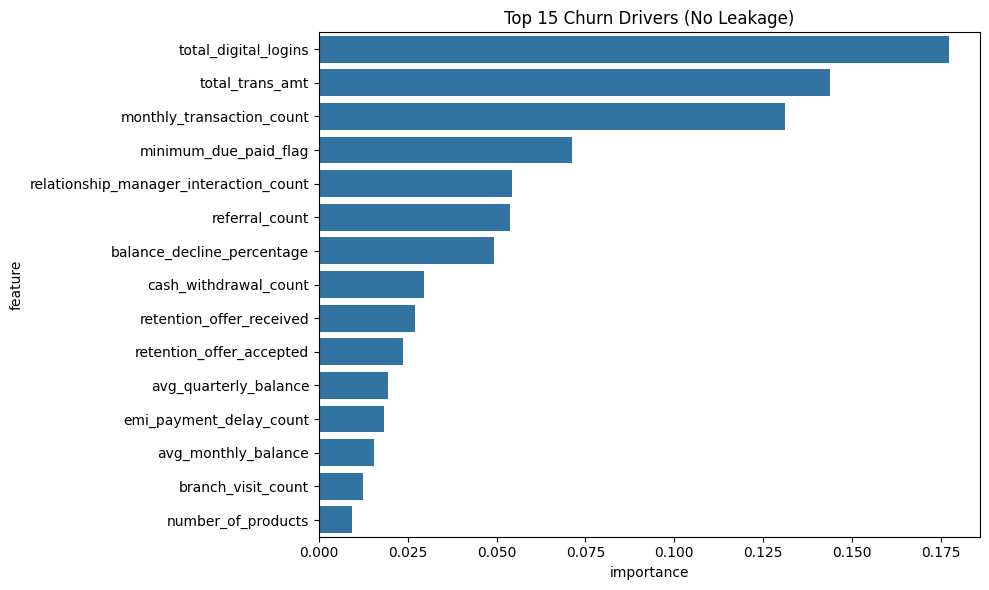

In [28]:
importance = final_model.feature_importances_
feature_names = X.columns
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
imp_df = imp_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df, x='importance', y='feature')
plt.title('Top 15 Churn Drivers (No Leakage)')
plt.tight_layout()
plt.savefig('../Models/feature_importance_corrected.png', dpi=150)
plt.show()

In [29]:
print("FINAL MODEL SUMMARY (NO DATA LEAKAGE):")
print(f"Validation PR-AUC: {pr_auc:.4f}")
print(f"Validation F1 (optimal threshold {best_thresh:.2f}): {f1_opt:.4f}")
print(f"Validation business cost: {min_cost:.0f} (FN={fn}, FP={fp})")
print(f"Test predictions generated: {len(submission)} rows")
print("\nTop 5 churn drivers:")
print(imp_df.head(5).to_string(index=False))
print("\nNo leakage: All preprocessing fit only on training data.")

FINAL MODEL SUMMARY (NO DATA LEAKAGE):
Validation PR-AUC: 0.9992
Validation F1 (optimal threshold 0.02): 0.9372
Validation business cost: 17500 (FN=0, FP=35)
Test predictions generated: 2026 rows

Top 5 churn drivers:
                               feature  importance
                  total_digital_logins    0.177207
                       total_trans_amt    0.143965
             monthly_transaction_count    0.131198
                 minimum_due_paid_flag    0.071194
relationship_manager_interaction_count    0.054429

No leakage: All preprocessing fit only on training data.
